# Churn Prediction

In [195]:
# Churn means not to use service any longer
# If customers churn between different companies that provide a particular service, 
# they change repeatedly from one to another.
# You have to offer them something so that they can stay like, discounts, lowering the price for them
# But here the important thing is you have to give discounts only to the customer who are going to churn.
# Binary Classification: g(x_i) \approx y_i =likelihood of churn
# g(x_i)=either 0 (stay) or 1 (leave)
# 

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [197]:
data=pd.read_csv('F:\Python Exercises from DataClub\Customer Churning/Telco-Customer-Churn.csv')

In [198]:
# data.head()

In [199]:
df=data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [200]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [201]:
df.columns=df.columns.str.lower().str.replace(' ','_') 
categorical_columns=list(df.dtypes[df.dtypes=='object'].index)

for c in categorical_columns:
    df[c]=df[c].str.lower().str.replace(' ','_')
    

In [202]:
df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [203]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [204]:
tc=pd.to_numeric(df.totalcharges, errors='coerce')

In [205]:
df[tc.isnull()][['customerid', 'totalcharges']]

,customerid,totalcharges
488,4472-lvygi,_
753,3115-czmzd,_
936,5709-lvoeq,_
1082,4367-nuyao,_
1340,1371-dwpaz,_
3331,7644-omvmy,_
3826,3213-vvolg,_
4380,2520-sgtta,_
5218,2923-arzlg,_
6670,4075-wkniu,_


In [206]:
df.totalcharges=pd.to_numeric(df.totalcharges, errors='coerce')

In [207]:
## Maybe it is not the best approach, but in practice its fine
df.totalcharges=df.totalcharges.fillna(0)

In [208]:
df.churn.head()
df.churn=(df.churn=='yes').astype('int')

## Setting up the validation framework
--> Perform the train/val/test split with sklearn

In [209]:
from sklearn.model_selection import train_test_split

In [210]:
df_full_train, df_test=train_test_split(df, test_size=0.2, random_state=1)

In [211]:
len(df_full_train), len(df_test)

(5634, 1409)

In [212]:
df_train, df_val=train_test_split(df_full_train, test_size=0.25, random_state=1)

In [213]:
len(df_train),len(df_val), len(df_test)

(4225, 1409, 1409)

In [214]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [215]:
y_train=df_train['churn']
y_val=df_val['churn']
y_test=df_test['churn']

In [216]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [217]:
df_test.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
0,8879-zkjof,female,0,no,no,41,yes,no,dsl,yes,no,yes,yes,yes,yes,one_year,yes,bank_transfer_(automatic),79.85,3320.75
1,0201-mibol,female,1,no,no,66,yes,yes,fiber_optic,yes,no,no,no,yes,yes,two_year,yes,bank_transfer_(automatic),102.40,6471.85
2,1600-dilpe,female,0,no,no,12,yes,no,dsl,no,no,no,no,no,no,month-to-month,yes,bank_transfer_(automatic),45.00,524.35
3,8601-qacrs,female,0,no,no,5,yes,yes,dsl,no,no,no,no,no,no,month-to-month,yes,mailed_check,50.60,249.95
4,7919-zodzz,female,0,yes,yes,10,yes,no,dsl,no,yes,yes,no,no,yes,one_year,yes,mailed_check,65.90,660.05


## EDA
--> Check missing values
--> Look at the target variable (churn)
--> Look at numerical and categorical variable

In [218]:
df_full_train=df_full_train.reset_index(drop=True)

In [219]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [220]:
df_full_train.churn.value_counts()

0    4113
1    1521
Name: churn, dtype: int64

In [221]:
# So this churn rate % 
# Like 26% is our global churn tate
df_full_train.churn.value_counts(normalize=True)

0    0.730032
1    0.269968
Name: churn, dtype: float64

In [222]:
global_churn=df_full_train.churn.mean()
global_churn

0.26996805111821087

In [223]:
numerical=['tenure', 'monthlycharges', 'totalcharges']

In [224]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='object')

In [225]:
categorical=[ 'gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [226]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## Feature Importance: Churn rate and risk ratio
Features importance analysis
1) Churn rate
2) Risk ratio
3) Mutual information

#### Churn rate

In [227]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-pptjy,male,0,yes,yes,12,yes,no,no,no_internet_service,...,no_internet_service,no_internet_service,no_internet_service,no_internet_service,two_year,no,mailed_check,19.70,258.35,0
1,6261-rcvns,female,0,no,no,42,yes,no,dsl,yes,...,yes,yes,no,yes,one_year,no,credit_card_(automatic),73.90,3160.55,1
2,2176-osjuv,male,0,yes,no,71,yes,yes,dsl,yes,...,no,yes,no,no,two_year,no,bank_transfer_(automatic),65.15,4681.75,0
3,6161-erdgd,male,0,yes,yes,71,yes,yes,dsl,yes,...,yes,yes,yes,yes,one_year,no,electronic_check,85.45,6300.85,0
4,2364-ufrom,male,0,no,no,30,yes,no,dsl,yes,...,no,yes,yes,no,one_year,no,electronic_check,70.40,2044.75,0


In [228]:
churn_female=df_full_train[df_full_train.gender=='female'].churn.mean()

In [229]:
churn_male=df_full_train[df_full_train.gender=='male'].churn.mean()

In [230]:
# The important thing is here to decide which features are the most important ones, that's the most difficult part.
# Like partner and no partner
churn_partner=df_full_train[df_full_train.partner=='yes'].churn.mean()

In [231]:
churn_no_partner=df_full_train[df_full_train.partner=='no'].churn.mean()
churn_no_partner

0.3298090040927694

In [232]:
global_churn-churn_partner

0.06493474245795922

In [233]:
global_churn-churn_no_partner

-0.05984095297455855

In [234]:
global_churn-churn_male

0.006754520462819769

#### Risk ratio

In [235]:
## Risk= group/global--> if >1-- implies more likely to churn
# <1--implies less likely to churn
# People with partner--> Low risk
churn_no_partner/global_churn

1.2216593879412643

In [236]:
# The people with no partner has high risk to churn
churn_partner/global_churn

0.7594724924338315

In [237]:
df_full_train.groupby('gender').churn.agg(['mean', 'count'])

,mean,count
gender,,
female,0.276824,2796
male,0.263214,2838


In [238]:
df_group=df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff']=df_group['mean']-global_churn
df_group['risk']=df_group['mean']/global_churn
df_group


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980


In [239]:
for c in categorical:
    print(c)
    df_group=df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff']=df_group['mean']-global_churn
    df_group['risk']=df_group['mean']/global_churn
    display(df_group)
    print()
    print()


gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,0.006856,1.025396
male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,0.161733,1.599082
one_year,0.120573,1186,-0.149395,0.446621
two_year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,-0.097897,0.637375
yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,-0.101797,0.622928
credit_card_(automatic),0.164339,1217,-0.105630,0.608733
electronic_check,0.455890,1893,0.185922,1.688682
mailed_check,0.193870,1305,-0.076098,0.718121


## Feature Importance: Mutual information
Mutual information--Concept from information theory, it tells us how much we can learn about 
one variable if we know the value of another

In [240]:
from sklearn.metrics import mutual_info_score

In [241]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0983203874041556

In [242]:
mutual_info_score(df_full_train.churn, df_full_train.partner)

0.009967689095399745

In [243]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)


In [244]:
# Important features are mi>0.04. Variables like that are very important like contract (m-to-m), these are pretty
# signals that machine learning models pick when training and it learns these kind of patterns, 
# what allows the model to actually make predictions, and then apply it to new data
# where we don't know what the churn rate is for new customers 

mi=df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

In [245]:
mi[mi>0.04]

internetservice     0.055868
onlinesecurity      0.063085
onlinebackup        0.046923
deviceprotection    0.043453
techsupport         0.061032
contract            0.098320
paymentmethod       0.043210
dtype: float64

## Feature Importance: Correlation

In [246]:
# -1 <=r <=1
# Increase in one variable means that other variable grows together with it.
# Correlation is between 0.0 and 0.2--> that is low correlation but that rarely happens
# Moderate correlation can be between 0.2 - 0.5, it happen sometimes
# Strong correlation between 0.6 - 1.0, it happen always
# y\in {0,1}, x \in R
# When higher tenure, higher the churn rate
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [247]:
# When tenure increases as churn rate decreases
# The more people pay (the higher the monthly charges are), will increase the churn rate
df_full_train[df_full_train.tenure<=2].churn.mean()

0.5953420669577875

In [248]:
df_full_train[(df_full_train.tenure>2) & (df_full_train.tenure<=12)].churn.mean()

0.3994413407821229

In [249]:
df_full_train[df_full_train.tenure>12].churn.mean()

0.17634908339788277

In [250]:
df_full_train[df_full_train.monthlycharges<=20].churn.mean()

0.08795411089866156

In [251]:
df_full_train[(df_full_train.monthlycharges>20)&(df_full_train.monthlycharges<=50)].churn.mean()

0.18340943683409436

In [252]:
df_full_train[df_full_train.monthlycharges>50].churn.mean()

0.32499341585462205

In [253]:
# For Tenure is it negatively correlated to Churn.
# But Monthly charges are positively correlated to Churn rate.
df_full_train[numerical].corrwith(df_full_train.churn).abs()

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

## One-hot encoding

In [254]:
# For example we have two variables: Gender and Contract
# What we do is make possible gender and contract mix like: 1 years contract for female
# and 1 years contract for male will be different.
# So we build a matrix for 5 columns
# Then we mark 0 for evrything that is not 1 year contract for female and 1 year contract for male
# 'All depends on the customers what type of contract they have'.


In [255]:
from sklearn.feature_extraction import DictVectorizer

In [256]:
df_train[['gender', 'contract']].iloc[:10].to_dict(orient='records')

[{'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'male', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'month-to-month'},
 {'gender': 'female', 'contract': 'two_year'},
 {'gender': 'female', 'contract': 'month-to-month'}]

In [257]:
dicts=df_train[['gender', 'contract']].iloc[:100].to_dict(orient='records')

In [258]:
dv=DictVectorizer(sparse=False)
dv.fit(dicts)

DictVectorizer(sparse=False)

In [259]:
dv.get_feature_names()

D:\Anaconda\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'gender=female',
 'gender=male']

In [260]:
dv.transform(dicts)

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0.],
       [1., 0.

In [261]:
train_dicts=df_train[categorical+numerical].to_dict(orient='records')

In [262]:
train_dicts[0]

{'gender': 'female',
 'seniorcitizen': 0,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'yes',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'yes',
 'onlinebackup': 'yes',
 'deviceprotection': 'yes',
 'techsupport': 'yes',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'two_year',
 'paperlessbilling': 'yes',
 'paymentmethod': 'electronic_check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [263]:
dv=DictVectorizer(sparse=False)
dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [264]:
dv.get_feature_names()

['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'dependents=no',
 'dependents=yes',
 'deviceprotection=no',
 'deviceprotection=no_internet_service',
 'deviceprotection=yes',
 'gender=female',
 'gender=male',
 'internetservice=dsl',
 'internetservice=fiber_optic',
 'internetservice=no',
 'monthlycharges',
 'multiplelines=no',
 'multiplelines=no_phone_service',
 'multiplelines=yes',
 'onlinebackup=no',
 'onlinebackup=no_internet_service',
 'onlinebackup=yes',
 'onlinesecurity=no',
 'onlinesecurity=no_internet_service',
 'onlinesecurity=yes',
 'paperlessbilling=no',
 'paperlessbilling=yes',
 'partner=no',
 'partner=yes',
 'paymentmethod=bank_transfer_(automatic)',
 'paymentmethod=credit_card_(automatic)',
 'paymentmethod=electronic_check',
 'paymentmethod=mailed_check',
 'phoneservice=no',
 'phoneservice=yes',
 'seniorcitizen',
 'streamingmovies=no',
 'streamingmovies=no_internet_service',
 'streamingmovies=yes',
 'streamingtv=no',
 'streamingtv=no_internet_servic

In [265]:
dv.transform(train_dicts[:5])

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 1.15500e+02, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 9.52500e+01, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.0

In [266]:
X_train=dv.fit_transform(train_dicts)

In [267]:
val_dicts=df_val[categorical+numerical].to_dict(orient='records')

In [268]:
dv=DictVectorizer(sparse=False)

In [269]:
dv=DictVectorizer()
train_dict=df_train[categorical+numerical].to_dict(orient='records')
X_train=dv.fit_transform(train_dict)

val_dict=df_val[categorical+numerical].to_dict(orient='records')
X_val=dv.transform(val_dict)

## Logistic Regression

In [270]:
# g(x_i)=y_i 
# Dependind on the 'y', we have different kind of machine learning methods
# We can have either regression or classification
# We can look now at Binary classification
# g(x_i) in this case outputs either 0 or 1.
# We have bias term here as well, and we usually use here 'sigmoid' function.
# g(x_i)=SIGMOID(w+w_i * x_i)


In [271]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [272]:
z=np.linspace(-5,5,51)

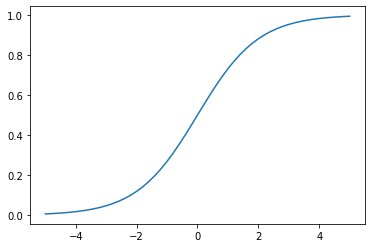

In [273]:
plt.plot(z,sigmoid(z))

In [274]:
def linear_regression(xi):
    result = w0
    for j in range(len(w)):
        result =result+xi[j]*w[j]
    return result

In [275]:
def logistic_regression(xi):
    score=w0
    for j in range(len(w)):
        score=score+xi[j]*w[j]
    result=sigmoid(score)
    return result

## Training logistic regression

In [276]:
from sklearn.linear_model import LogisticRegression

In [277]:
model = LogisticRegression()
model.fit(X_train, y_train)

D:\Anaconda\lib\site-packages\sklearn\linear_model\_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


LogisticRegression()

In [281]:
model.intercept_[0]

-0.10854916738760084

In [280]:
model.coef_[0].round(3)

array([ 0.478, -0.176, -0.41 , -0.029, -0.079,  0.063, -0.088, -0.082,
       -0.034, -0.073, -0.338,  0.318, -0.088,  0.004, -0.258,  0.142,
        0.009,  0.062, -0.088, -0.082,  0.267, -0.088, -0.286, -0.232,
        0.124, -0.165,  0.058, -0.087, -0.032,  0.071, -0.058,  0.142,
       -0.249,  0.217, -0.121, -0.088,  0.102, -0.072, -0.088,  0.052,
        0.214, -0.088, -0.234, -0.07 ,  0.   ])

In [285]:
# These are hard predictions
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1])

In [291]:
# These are the soft predictions
# But we don't need the above, we need the predict probabilities and this is what we do below
# This is also a score
# The first column shows the probability of not churning
# The second column is probability of churning
y_pred=model.predict_proba(X_train)[:,1]

In [293]:
y_pred=model.predict_proba(X_val)[:,1]

In [297]:
y_pred>=0.5

array([False, False, False, ..., False,  True,  True])

In [299]:
# All the people who will get the promotional emails from the company
churn_decision=(y_pred>=0.5)

In [300]:
df_val[churn_decision]

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges
3,8433-wxgna,male,0,no,no,2,yes,no,fiber_optic,yes,no,no,no,no,no,month-to-month,yes,electronic_check,75.70,189.20
8,3440-jpscl,female,0,no,no,6,yes,no,fiber_optic,no,no,yes,yes,yes,yes,month-to-month,yes,mailed_check,99.95,547.65
11,2637-fkfsy,female,0,yes,no,3,yes,no,dsl,no,no,no,no,no,no,month-to-month,yes,mailed_check,46.10,130.15
12,7228-omtpn,male,0,no,no,4,yes,no,fiber_optic,no,no,no,no,yes,yes,month-to-month,yes,electronic_check,88.45,370.65
19,6711-fldfb,female,0,no,no,7,yes,yes,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,74.90,541.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1397,5976-jcjrh,male,0,yes,no,10,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,70.30,738.20
1398,2034-cgrhz,male,1,no,no,24,yes,yes,fiber_optic,no,yes,yes,no,yes,yes,month-to-month,yes,credit_card_(automatic),102.95,2496.70
1399,5276-kqwhg,female,1,no,no,2,yes,no,fiber_optic,no,no,no,no,no,no,month-to-month,yes,electronic_check,69.60,131.65
1407,6521-yytyi,male,0,no,yes,1,yes,yes,fiber_optic,no,no,no,no,yes,yes,month-to-month,yes,electronic_check,93.30,93.30


In [304]:
# These are the people who will receive promotional emails
df_val[churn_decision].customerid

3       8433-wxgna
8       3440-jpscl
11      2637-fkfsy
12      7228-omtpn
19      6711-fldfb
           ...    
1397    5976-jcjrh
1398    2034-cgrhz
1399    5276-kqwhg
1407    6521-yytyi
1408    3049-solay
Name: customerid, Length: 313, dtype: object

In [305]:
# Let's now check how accurate our predictions are. We used RMSE for linear regression, 
# here will use something similar to measure how accurate our predictions were
# We will use accuracy here
churn_decision.astype(int)

array([0, 0, 0, ..., 0, 1, 1])

In [306]:
(y_val==churn_decision).mean()

0.8034066713981547

In [307]:
df_pred=pd.DataFrame()
df_pred['probability']=y_pred
df_pred['prediction']=churn_decision.astype(int)
df_pred['actual']=y_val
df_pred

,probability,prediction,actual
0,0.008949,0,0
1,0.206644,0,0
2,0.214677,0,0
3,0.543660,1,1
4,0.216033,0,0
...,...,...,...
1404,0.315527,0,0
1405,0.039302,0,1
1406,0.136402,0,0
1407,0.800488,1,1


In [308]:
df_pred['correct']=df_pred.prediction==df_pred.actual
df_pred

,probability,prediction,actual,correct
0,0.008949,0,0,True
1,0.206644,0,0,True
2,0.214677,0,0,True
3,0.543660,1,1,True
4,0.216033,0,0,True
...,...,...,...,...
1404,0.315527,0,0,True
1405,0.039302,0,1,False
1406,0.136402,0,0,True
1407,0.800488,1,1,True


In [310]:
# This is all that in this line (y_val==churn_decision).mean()
df_pred.correct.mean()

0.8034066713981547

## Model interpretation

In [311]:
dv.get_feature_names()

D:\Anaconda\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'dependents=no',
 'dependents=yes',
 'deviceprotection=no',
 'deviceprotection=no_internet_service',
 'deviceprotection=yes',
 'gender=female',
 'gender=male',
 'internetservice=dsl',
 'internetservice=fiber_optic',
 'internetservice=no',
 'monthlycharges',
 'multiplelines=no',
 'multiplelines=no_phone_service',
 'multiplelines=yes',
 'onlinebackup=no',
 'onlinebackup=no_internet_service',
 'onlinebackup=yes',
 'onlinesecurity=no',
 'onlinesecurity=no_internet_service',
 'onlinesecurity=yes',
 'paperlessbilling=no',
 'paperlessbilling=yes',
 'partner=no',
 'partner=yes',
 'paymentmethod=bank_transfer_(automatic)',
 'paymentmethod=credit_card_(automatic)',
 'paymentmethod=electronic_check',
 'paymentmethod=mailed_check',
 'phoneservice=no',
 'phoneservice=yes',
 'seniorcitizen',
 'streamingmovies=no',
 'streamingmovies=no_internet_service',
 'streamingmovies=yes',
 'streamingtv=no',
 'streamingtv=no_internet_servic

In [312]:
dict(zip(dv.get_feature_names(), model.coef_[0].round(3)))

{'contract=month-to-month': 0.478,
 'contract=one_year': -0.176,
 'contract=two_year': -0.41,
 'dependents=no': -0.029,
 'dependents=yes': -0.079,
 'deviceprotection=no': 0.063,
 'deviceprotection=no_internet_service': -0.088,
 'deviceprotection=yes': -0.082,
 'gender=female': -0.034,
 'gender=male': -0.073,
 'internetservice=dsl': -0.338,
 'internetservice=fiber_optic': 0.318,
 'internetservice=no': -0.088,
 'monthlycharges': 0.004,
 'multiplelines=no': -0.258,
 'multiplelines=no_phone_service': 0.142,
 'multiplelines=yes': 0.009,
 'onlinebackup=no': 0.062,
 'onlinebackup=no_internet_service': -0.088,
 'onlinebackup=yes': -0.082,
 'onlinesecurity=no': 0.267,
 'onlinesecurity=no_internet_service': -0.088,
 'onlinesecurity=yes': -0.286,
 'paperlessbilling=no': -0.232,
 'paperlessbilling=yes': 0.124,
 'partner=no': -0.165,
 'partner=yes': 0.058,
 'paymentmethod=bank_transfer_(automatic)': -0.087,
 'paymentmethod=credit_card_(automatic)': -0.032,
 'paymentmethod=electronic_check': 0.071,


In [313]:
# We  will take a small subset of these all values above
small=['contract', 'tenure', 'monthlycharges']
df_train[small].iloc[:10].to_dict(orient='records')

[{'contract': 'two_year', 'tenure': 72, 'monthlycharges': 115.5},
 {'contract': 'month-to-month', 'tenure': 10, 'monthlycharges': 95.25},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 75.55},
 {'contract': 'month-to-month', 'tenure': 5, 'monthlycharges': 80.85},
 {'contract': 'two_year', 'tenure': 18, 'monthlycharges': 20.1},
 {'contract': 'month-to-month', 'tenure': 4, 'monthlycharges': 30.5},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 75.1},
 {'contract': 'month-to-month', 'tenure': 1, 'monthlycharges': 70.3},
 {'contract': 'two_year', 'tenure': 72, 'monthlycharges': 19.75},
 {'contract': 'month-to-month', 'tenure': 6, 'monthlycharges': 109.9}]

In [314]:
dict_train_small=df_train[small].to_dict(orient='records')
dict_val_small=df_val[small].to_dict(orient='records')

In [316]:
dv_small=DictVectorizer(sparse=False)
dv_small.fit(dict_train_small)

DictVectorizer(sparse=False)

In [317]:
dv_small.get_feature_names()

['contract=month-to-month',
 'contract=one_year',
 'contract=two_year',
 'monthlycharges',
 'tenure']

In [318]:
X_train_small=dv_small.transform(dict_train_small)

In [319]:
model_small=LogisticRegression()
model_small.fit(X_train_small, y_train)

LogisticRegression()

In [320]:
# This is the intercept of the small dataset
w0=model_small.intercept_[0]
w0

-2.4767756632262654

In [324]:
# These are "w's" of the small dataset
w=model_small.coef_[0]
w.round(3)

array([ 0.97 , -0.025, -0.949,  0.027, -0.036])

In [325]:
dict(zip(dv_small.get_feature_names(), w.round(3)))

D:\Anaconda\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


{'contract=month-to-month': 0.97,
 'contract=one_year': -0.025,
 'contract=two_year': -0.949,
 'monthlycharges': 0.027,
 'tenure': -0.036}

In [334]:
-2.47+0.97+50*0.027+5*(-0.036)

-0.3300000000000001

In [335]:
# Example customer has a monthly contract so it will be like this, and we assume that he is with our company for 
# 5 years and is paying 50$ per month, so it will be like as below:
# -2.47+1*0.97+0+0+20*0.027+5*(-0.036), the 0's are for because the customer has a monthly contract and not a yearly or a 2year 
# 
sigmoid(_)
# We are using '_' because it is a magic operator in jupyter notebooks, which means use the result of the last cell.

0.41824062315816374

In [339]:
-2.47+0.97+60*0.027+1*(-0.036)

0.08399999999999966

In [340]:
sigmoid(-2.47+0.97+60*0.027+1*(-0.036))

0.5209876607065322

In [341]:
sigmoid(-2.47+(-0.949)+30*0.027+24*(-0.036))

0.030090303318277657

In [ ]:
sigmoid(-2.47+( -0.949)+30*0.027+24*(-0.036))

## Using the model

In [343]:
dicts_full_train=df_full_train[categorical+numerical].to_dict(orient='records')

In [345]:
dv=DictVectorizer(sparse=False)
X_full_train=dv.fit_transform(dicts_full_train)
y_full_train=df_full_train.churn.values

In [346]:
model=LogisticRegression()
model.fit(X_full_train, y_full_train)

LogisticRegression()

In [347]:
dicts_test=df_test[categorical+numerical].to_dict(orient='records')

In [349]:
dicts_test

[{'gender': 'female',
  'seniorcitizen': 0,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'no',
  'internetservice': 'dsl',
  'onlinesecurity': 'yes',
  'onlinebackup': 'no',
  'deviceprotection': 'yes',
  'techsupport': 'yes',
  'streamingtv': 'yes',
  'streamingmovies': 'yes',
  'contract': 'one_year',
  'paperlessbilling': 'yes',
  'paymentmethod': 'bank_transfer_(automatic)',
  'tenure': 41,
  'monthlycharges': 79.85,
  'totalcharges': 3320.75},
 {'gender': 'female',
  'seniorcitizen': 1,
  'partner': 'no',
  'dependents': 'no',
  'phoneservice': 'yes',
  'multiplelines': 'yes',
  'internetservice': 'fiber_optic',
  'onlinesecurity': 'yes',
  'onlinebackup': 'no',
  'deviceprotection': 'no',
  'techsupport': 'no',
  'streamingtv': 'yes',
  'streamingmovies': 'yes',
  'contract': 'two_year',
  'paperlessbilling': 'yes',
  'paymentmethod': 'bank_transfer_(automatic)',
  'tenure': 66,
  'monthlycharges': 102.4,
  'totalcharges': 6471.85},
 {'gend

In [350]:
X_test=dv.transform(dicts_test)

In [351]:
y_pred=model.predict_proba(X_test)[:,1]

In [352]:
y_pred

array([0.06224296, 0.17473875, 0.37026701, ..., 0.00638005, 0.16576097,
       0.59688521])

In [353]:
y_pred>=0.5

array([False, False, False, ..., False, False,  True])

In [354]:
churn_decision=(y_pred>=0.5)

In [355]:
(churn_decision==y_test).mean()

0.815471965933286

In [356]:
dicts_test[10]

{'gender': 'male',
 'seniorcitizen': 1,
 'partner': 'yes',
 'dependents': 'yes',
 'phoneservice': 'yes',
 'multiplelines': 'no',
 'internetservice': 'fiber_optic',
 'onlinesecurity': 'no',
 'onlinebackup': 'yes',
 'deviceprotection': 'no',
 'techsupport': 'no',
 'streamingtv': 'yes',
 'streamingmovies': 'yes',
 'contract': 'month-to-month',
 'paperlessbilling': 'yes',
 'paymentmethod': 'mailed_check',
 'tenure': 32,
 'monthlycharges': 93.95,
 'totalcharges': 2861.45}

In [359]:
# He is a male, senior citizen, put his monthly charges are too high.
customer=dicts_test[10]


In [361]:
X_small=dv.transform([customer])

In [363]:
# He has a chance of only 40% churning 
model.predict_proba(X_small)

array([[0.5943189, 0.4056811]])

In [365]:
# This customer has 60% chance of churning that's why she will get a promotional email.
customer=dicts_test[-1]
X_small=dv.transform([customer])
model.predict_proba(X_small)


array([[0.40311479, 0.59688521]])

In [374]:
y_test.iloc[1407]

0